In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2

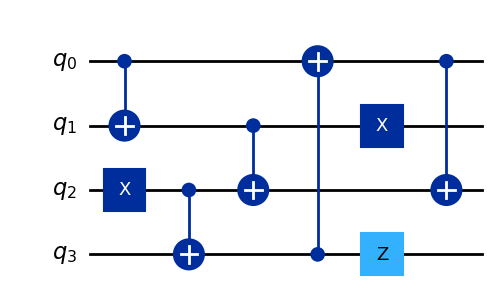

In [2]:
qc = QuantumCircuit(4)
qc.cx(0,1)
qc.x(2)
qc.cx(2,3)
qc.cx(1,2)
qc.x(1)
qc.cx(3,0)
qc.z(3)
qc.cx(0,2)

# 2D grid topology (3x3)
# Qubits arranged as:
#  0 - 1 - 2
#  |   |   |
#  3 - 4 - 5
#  |   |   |
#  6 - 7 - 8

complex_coupling = [
    # Horizontal edges
    [0, 1], [1, 2],
    [3, 4], [4, 5],
    [6, 7], [7, 8],
    # Vertical edges
    [0, 3], [3, 6],
    [1, 4], [4, 7],
    [2, 5], [5, 8],
]

backend_complex = GenericBackendV2(
    num_qubits=9,
    basis_gates=["x", "sx", "rz", "cx"],
    coupling_map=complex_coupling,
    seed=123
)
qc.draw("mpl")

Distance matrix:
 [[0, 1, 1, 2], [1, 0, 2, 1], [1, 2, 0, 3], [2, 1, 3, 0]]
Performing swap: (2, 0) to resolve dependency: g1
-----------------------------------------------------------

Performing swap: (2, 1) to resolve dependency: g1
-----------------------------------------------------------

Performing swap: (3, 2) to resolve dependency: g3
-----------------------------------------------------------

Performing swap: (3, 1) to resolve dependency: g3
-----------------------------------------------------------

Performing swap: (0, 3) to resolve dependency: g4
-----------------------------------------------------------

Performing swap: (0, 1) to resolve dependency: g4
-----------------------------------------------------------



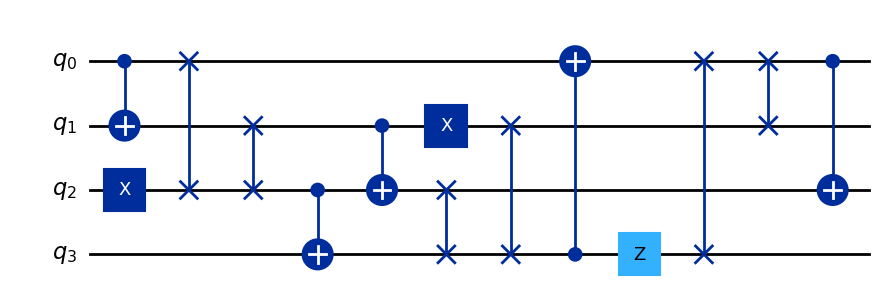

In [3]:
qc = Layout.run_layout(qc, backend_complex)
qc.draw("mpl")